# Nome: Gabriel Delgado Panovich de Barros

# RA: 176313

# Sobre o dataset
---
> Este arquivo foi copiado diretamente da [fonte](https://www.kaggle.com/datasets/jackogozaly/steam-player-data/data) dos dados, com exceção das imagens.

## Context
This dataset contains the average players by month for the current top 100 games. It was scraped off https://steamcharts.com/top and converted into this easier to analyze format.

# Objetivo do projeto
---
Este projeto visa predizer a quantidade média de jogadores do jogo Warframe através de um modelo de rede recorrente LSTM. Para isso, foram analisadas 5 topologias distintas, a fim de encontrar o modelo que mais se adapte à situação apresentada.

Como o dataset apresenta dados sobre os 100 jogos mais famosos da Steam, foi feita a filtragem a fim de manter apenas do jogo desejado. Além disso, foram utilizadas as colunas de quantidade média de jogadores, ganho de jogadores e porcentagem de ganho, organizadas em uma série temporal.

---

# Importações

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from typing import Dict, Tuple

# Preparação dos dados

In [2]:
def normalizeDataset(df: pd.DataFrame, mean: pd.Series, std: pd.Series) -> pd.DataFrame:
    """
    Função auxiliar que aplica normalização no conjunto de dados.

    Args:
        df: DataFrame com os dados que serão utilizados.
        mean: Média do dataset de treino.
        std: Desvio padrão do dataset de treino.

    Output:
        Dataframe normalizado no formato pd.DataFrame.
    """
    return (df - mean) / std

def createSequences(data: np.ndarray, seq_len: int, target_idx: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Função auxiliar que prepara os dados para serem inseridos no formato de
    série temporal no tensor conforme a janela temporal indicada.

    Args:
        data: Dados da série.
        seq_len: Tamanho da janela temporal.
        target_idx: Índice da coluna que utilizaremos para a predição.

    Output:
        Retorna a janela temporal e o valor de predição, ambos como ndarrays.
    """
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len]) # janela multivariada = X
        y.append(data[i + seq_len, target_idx])   # valor futuro = y

    return np.array(X), np.array(y)

def prepareData(path: str, batch_size: int = 32) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Carrega os dados em formato de um DataLoader.

    Args:
        path: Caminho para o arquivo .csv que contém os dados.
        batch_size: Tamanho dos lotes de treinamento.

    Output:
        Retorna os dados separados conforme a proporção 75%, 15%, 15% como dataloaders
    """
    # --- 1. Montagem do DataFrame ---
    df = pd.read_csv(path)

    # --- 2. Normalização e separação dos conjuntos ---
    full_size = len(df)
    train_size = int(0.75 * full_size)
    val_size = int(0.15 * full_size)
    # Precisamos fazer essa inversão pois a série apresenta os valores mais recentes
    # nas primeiras linhas e os mais antigos nas últimas.
    df = df.iloc[::-1].reset_index(drop=True)
    # Esta etapa conserta o erro de geração de NaNs.
    df.loc[[0, 1], 'Gain'] = 0.0
    df.loc[[0, 1], 'Percent_Gain'] = 0.0
    
    train_df = df.iloc[:train_size]
    val_df = df.iloc[train_size:(train_size + val_size)]
    test_df = df.iloc[(train_size + val_size):]

    mean = train_df.mean(axis=0)
    std = train_df.std(axis=0)
    train_df = normalizeDataset(train_df, mean, std)
    val_df = normalizeDataset(val_df, mean, std)
    test_df = normalizeDataset(test_df, mean, std)

    # --- 3. Criação das janelas temporais
    seq_len = 5 # janela de 5 sequências
    target_col = "Avg_players"
    target_idx = df.columns.get_loc(target_col)

    train_np = train_df.to_numpy()
    # Extensão da janela dos conjuntos de validação e teste
    val_extended = pd.concat([train_df.tail(seq_len), val_df])
    test_extended = pd.concat([val_df.tail(seq_len), test_df])

    val_np = val_extended.to_numpy()
    test_np = test_extended.to_numpy()

    X_train_np, y_train_np = createSequences(train_np, seq_len, target_idx)
    X_val_np, y_val_np = createSequences(val_np, seq_len, target_idx)
    X_test_np, y_test_np = createSequences(test_np, seq_len, target_idx)
    # Remoção das janelas extras, evitando data leakage
    if len(X_val_np) > seq_len:
        X_val_np = X_val_np[seq_len:]
        y_val_np = y_val_np[seq_len:]

    if len(X_test_np) > seq_len:
        X_test_np = X_test_np[seq_len:]
        y_test_np = y_test_np[seq_len:]

    # --- 4. Conversão para tensor ---
    X_train = torch.tensor(X_train_np, dtype=torch.float32)
    y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)

    X_val = torch.tensor(X_val_np, dtype=torch.float32)
    y_val = torch.tensor(y_val_np, dtype=torch.float32).unsqueeze(1)

    X_test = torch.tensor(X_test_np, dtype=torch.float32)
    y_test = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    test_dataset = TensorDataset(X_test, y_test)

    # --- 5. Criação dos dataloaders ---
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_dataloader, val_dataloader, test_dataloader, mean, std

def filterData(path: str = "db/") -> None:
    """
    Como desejamos apenas os dados do jogo Warframe, devemos remover todos os
    dados relativos a outros jogos, bem como manter apenas as features relevantes
    para o treinamento da rede.

    Args:
        path: Caminho da pasta do dataset.
    """
    arc_path = os.path.join(path, "Valve_Player_Data.csv")
    df = pd.read_csv(arc_path)

    labels = [
        "Month_Year",
        "Date"
    ]

    features = [
        "Avg_players",
        "Gain",
        "Percent_Gain",
    ]

    # Conversão das porcentagens em decimal
    df["Percent_Gain"] = df["Percent_Gain"].str.rstrip("%").astype(float) / 100

    warframe_df = df[df["Game_Name"] == "Warframe"]
    warframe_labels = warframe_df[labels]
    warframe_features = warframe_df[features]

    output_path_labels = os.path.join(path, "Warframe_Player_Data_Labels.csv")
    output_path_features = os.path.join(path, "Warframe_Player_Data_Features.csv")
    warframe_labels.to_csv(output_path_labels, index=False)
    warframe_features.to_csv(output_path_features, index=False)

# Funções de plotagem de gráficos para avaliação do modelo

In [3]:
PATH_FIG = "assets/"

def plotLosses(loss1: Dict[int, float],
               loss2: Dict[int ,float],
               loss1_label: str,
               loss2_label: str,
               saving: str) -> None:
    plt.close("all")
    plt.figure()
    plt.plot(loss1.keys(), loss1.values(), label=loss1_label)
    plt.plot(loss2.keys(), loss2.values(), label=loss2_label)
    plt.title(f"{loss1_label} e {loss2_label}")
    plt.xlabel("Épocas")
    plt.ylabel("Erro")
    plt.legend()
    plt.savefig(os.path.join(PATH_FIG, saving))
    plt.show()

def plotSeries(real_values: np.ndarray,
               predicted_values: np.ndarray,
               real_label: str,
               predicted_label: str,
               saving: str) -> None:
    plt.figure(figsize=(12, 6))
    plt.plot(real_values, label=real_label)
    plt.plot(predicted_values, label=predicted_label)
    plt.title("Série temporal - Valores reais vs previstos")
    plt.xlabel("Tempo")
    plt.ylabel("Average Players")
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(PATH_FIG, saving))
    plt.show()

# Funções de treinamento, validação e teste

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def trainEpoch(model: nn.Module,
               train_loader: DataLoader, 
               optimizer,
               loss_function: callable,
               device=DEVICE) -> float:
    """
    Função de treinamento do modelo, percorrendo uma época.

    Args:
        model: Modelo de rede neural a ser treinado.
        train_loader: DataLoader de treinamento.
        optimizer: Método de cálculo da retropropagação.
        loss_function: Função de erro definida pelo usuário.
        device: Dispositivo de aceleração utilizado.
    Output:
        Retorna a média do erro calculado nas iterações da época.
    """
    model.train()
    total_loss = 0.0

    # Itera sobre o dataloader
    for features, labels in train_loader:
        # --- 1. Enviamos os dados para o dispositivo de aceleração ---
        features = features.to(device)
        labels = labels.to(device)
        # --- 2. Zeramos o gradiente da classe de gradiente estocástico ---
        optimizer.zero_grad()
        # --- 3. Feedforward ---
        # Passamos os features como x1, x2, ..., xn para o modelo gerar uma saída
        predict = model(features)
        # --- 4. Cálculo do erro da saída ---
        # Aplicação da função de erro
        out_loss = loss_function(predict, labels) # args: (saída do modelo, saída esperada)
        # --- 5. Retropropagação ---
        out_loss.backward()
        # --- 6. Atualização dos pesos com base na retropropagação ---
        optimizer.step()

        # Convertemos o erro (tensor) em um valor numérico
        total_loss += out_loss.item()

    avg_loss = total_loss / len(train_loader)
    return avg_loss


def evaluateEpoch(model: nn.Module,
                  val_loader: DataLoader,
                  loss_function: callable,
                  device=DEVICE) -> float:
    """
    Função de validação do modelo, percorrendo uma época. Como não estamos treinando o modelo, não precisamos
    calcular o gradiente descendente estocástico, o qual é necessário para atualizar os pesos sinápticos dos
    neurônios das camadas ocultas.

    Args:
        model: Modelo de rede neural a ser treinado.
        val_loader: DataLoader de validação.
        loss_function: Função de erro definida pelo usuário.
        device: Dispositivo de aceleração utilizado.
    Output:
        Retorna a média do erro calculado nas iterações da época.
    """
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad(): # Desativa o cálculo do gradiente descendente para economizar processamento
        for features, labels in val_loader:
            # --- 1. Enviamos os dados para o dispositivo de aceleração ---
            features = features.to(device)
            labels = labels.to(device)
            # --- 2. Feedforward ---
            # Passamos os features como x1, x2, ..., xn para o modelo gerar uma saída
            predict = model(features)
            # --- 3. Cálculo do erro da saída ---
            out_loss = loss_function(predict, labels)
            # Convertemos o erro (tensor) em um valor numérico
            total_loss += out_loss.item()

    avg_loss = total_loss / len(val_loader)
    return avg_loss

def testModel(model: nn.Module,
              test_loader: DataLoader,
              mean: pd.Series,
              std: pd.Series,
              device=DEVICE) -> float:
    """
    Função de teste do modelo. Para ajuste das saídas, convertemos valores acima de 0.5 para 1.

    Args:
        model: Modelo de rede neural a ser treinado.
        test_loader: DataLoader de teste.
        mean: pd.Series que contém a média de cada coluna do dataset.
        std: pd.Series que contém o desvio padrão de cada coluna do dataset.
        device: Dispositivo de aceleração utilizado.
    Output:
        Retorna a acurácia média do modelo como float.
    """
    model.eval()
    mse_loss = 0.0
    mean_target = mean.iloc[0]
    std_target  = std.iloc[0]

    with torch.no_grad():
        for features, labels in test_loader:
            # --- 1. Enviamos os dados para o dispositivo de aceleração ---
            features = features.to(device)
            labels = labels.to(device)
            # --- 2. Feedforward ---
            # Passamos os features como x1, x2, ..., xn para o modelo gerar uma saída
            outputs = model(features)

            # Desnormalizar
            outputs_real = outputs * std_target + mean_target
            labels_real  = labels  * std_target + mean_target

            # --- 3. Contagem de samples e dos resultados corretos ---
            mse_loss += torch.mean((outputs_real - labels_real)**2).item()
    
    # --- 5. Calcula a acurácia final ---
    return (mse_loss / len(test_loader))**0.5

def generateSeries(model: nn.Module,
                   test_loader: DataLoader,
                   mean: pd.Series,
                   std: pd.Series) -> Tuple[np.ndarray, np.ndarray]:
    """
    Função auxiliar que gera a predição do modelo e prepara os dados para serem
    plotados em um gráfico de série temporal.

    Args:
        model: Modelo de rede neural.
        test_loader: DataLoader de teste.
        mean: pd.Series que contém a média de cada coluna do dataset.
        std: pd.Series que contém o desvio padrão de cada coluna do dataset.
    Output:
        Retorna uma tupla contendo umas série com os valores reais e os valores
        preditos, respectivamente.
    """
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            output = model(X_batch)

            preds.append(output.cpu().numpy())
            trues.append(y_batch.cpu().numpy())

        preds = np.concatenate(preds).flatten()
        trues = np.concatenate(trues).flatten()

    true_denorm = trues * std.iloc[0] + mean.iloc[0]
    pred_denorm = preds * std.iloc[0] + mean.iloc[0]

    return true_denorm, pred_denorm

# Modelo 1 - 1 neurônio na célula LSTM
---

## Resultados obtidos

Verificamos um decaimento do erros de treino e um crescimento do erro de validação, ambos bem lento. Isso pode ser resultado da taxa de aprendizado baixa ou da insuficiência do modelo para esse tipo de problema.

Mesmo com 300 épocas, o modelo não apresentou uma certa estagnação, o que indica que tem complexidade inferior ao problema. Em outras palavras, este caso descreve underfitting.

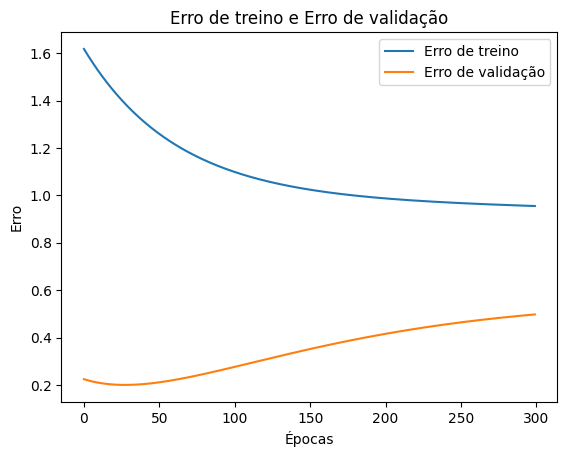

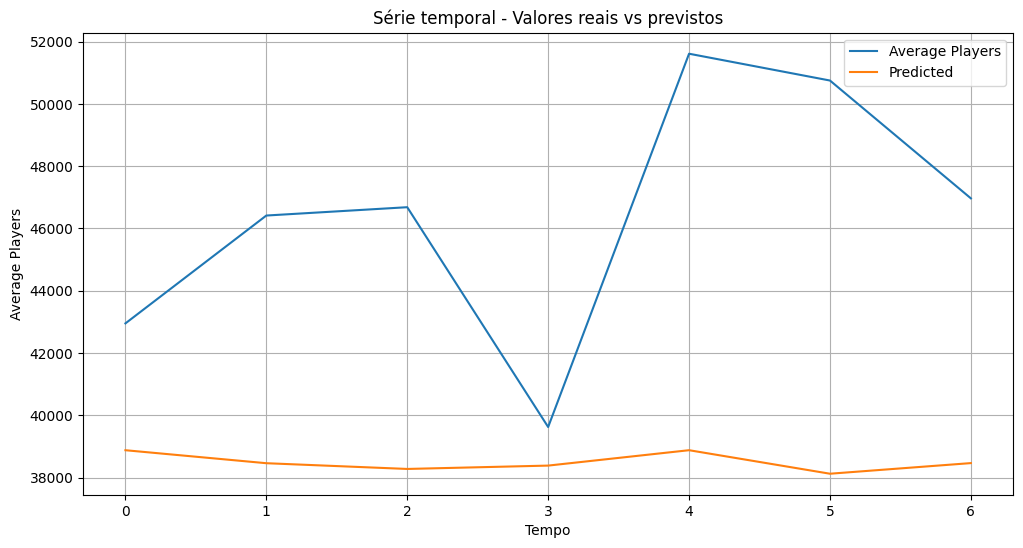

========= Erro de teste =========
8834.19


In [5]:
class LSTM(nn.Module):
    def __init__(self, in_features: int = 3, hidden_size: int = 1, out_features: int = 1):
        """
        Args:
            in_features: Número de features que o dataset possui (recebemos os 3 features)
            out_features: Previsão do modelo (prevemos apenas a quantidade média de jogadores)
        """
        super(LSTM, self).__init__() # instancia o nn.Module
        self.lstm = nn.LSTM(in_features, hidden_size=hidden_size, batch_first=True)
        # Camada de mapeamento
        self.l1 = nn.Linear(hidden_size, out_features)

    def forward(self, input):
        """
        Args:
            input: (batch_size, seq_len, in_features)
        """
        out, (a, c) = self.lstm(input)
        a_last = a[-1]
        
        out = self.l1(a_last)

        return out

EPOCHS = 300
BATCH_SIZE = 32
HIDDEN_SIZE = 1
ETA = 0.001
PATH = "db/Warframe_Player_Data_Features.csv"

# --- 1. Preparação dos dataloaders ---
train_dl, val_dl, test_dl, mean, std = prepareData(PATH)
# Exemplo de verificação de um lote de treino
# features, labels = next(iter(val_dl))
# print(f"Shape das features do lote de treino: {features.shape}")
# print(f"Shape dos labels do lote de treino: {labels.shape}")
# print(f"Exemplo de uma feature normalizada: {features[0]}")

# --- 2. Instanciação do modelo, da função de erro e do algoritmo de cálculo de gradiente ---
model = LSTM(hidden_size=HIDDEN_SIZE).to(DEVICE)
loss_func = nn.MSELoss()
optimizer = torch.optim.SGD(
   model.parameters(),
   lr = ETA 
)

# --- 3. Etapa de treinamento e validação ---
# Armazenamos os erros seguindo o padrão {época: erro obtido}
train_loss = {}
val_loss = {}
for i in range(EPOCHS):
    loss = trainEpoch(model, train_dl, optimizer, loss_func)
    train_loss[i] = loss

    loss = evaluateEpoch(model, val_dl, loss_func)
    val_loss[i] = loss

plotLosses(train_loss, val_loss, "Erro de treino", "Erro de validação", "Gráfico_de_erros_M1.png")
true_values, predicted_values = generateSeries(model, test_dl, mean, std)
plotSeries(true_values, predicted_values, "Average Players", "Predicted", "Grafico_serie_temporal1.png")
accuracy = testModel(model, test_dl, mean, std)
print("========= Erro de teste =========")
print(f"{accuracy:.2f}")

# Modelo 2 - 8 neurônios na célula LSTM
---

## Resultados obtidos

Verificamos, pelo gráfico da série temporal, que o modelo foi mais capaz de aprender a série, pois aproximou-se mais dos valores reais. Contudo, há um fenômeno estranho nos gráficos de erro: o erro de validação atinge valores mais baixos que o erro de teste. Para entender melhor esse comportamento, foi aumentado o número de épocas.

Uma possível explicação para esse fenômeno curioso é que, com uma distância maior da data de lançamento do jogo, padrões mais bem definidos são observados na quantidade média de jogadores. Por isso, o modelo apresentou uma capacidade melhor de trabalhar com o conjunto de validação, que está situado em datas mais atuais.

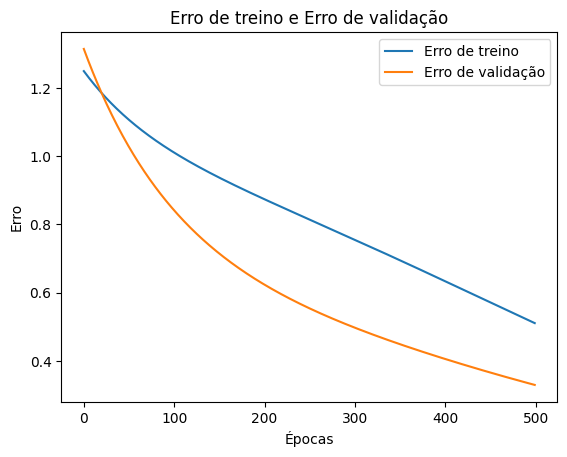

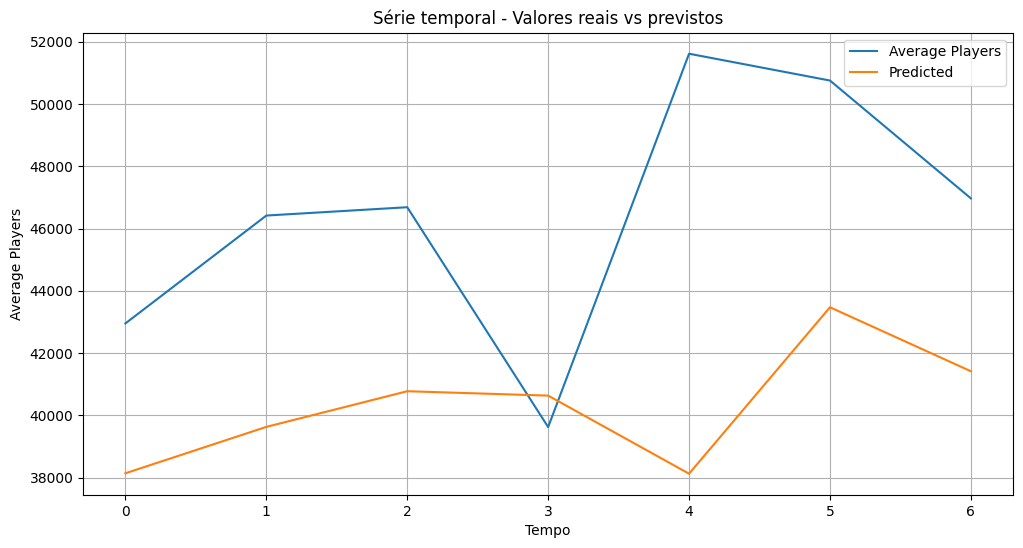

========= Erro de teste =========
7281.19


In [6]:
class LSTM(nn.Module):
    def __init__(self, in_features: int = 3, hidden_size: int = 8, out_features: int = 1):
        """
        Args:
            in_features: Número de features que o dataset possui (recebemos os 3 features)
            out_features: Previsão do modelo (prevemos apenas a quantidade média de jogadores)
        """
        super(LSTM, self).__init__() # instancia o nn.Module
        self.lstm = nn.LSTM(in_features, hidden_size=hidden_size, batch_first=True)
        # Camada de mapeamento
        self.l1 = nn.Linear(hidden_size, out_features)

    def forward(self, input):
        """
        Args:
            input: (batch_size, seq_len, in_features)
        """
        out, (a, c) = self.lstm(input)
        a_last = a[-1]
        
        out = self.l1(a_last)

        return out

EPOCHS = 500
BATCH_SIZE = 32
HIDDEN_SIZE = 8
ETA = 0.001
PATH = "db/Warframe_Player_Data_Features.csv"

# --- 1. Preparação dos dataloaders ---
train_dl, val_dl, test_dl, mean, std = prepareData(PATH)

# --- 2. Instanciação do modelo, da função de erro e do algoritmo de cálculo de gradiente ---
model = LSTM(hidden_size=HIDDEN_SIZE).to(DEVICE)
loss_func = nn.MSELoss()
optimizer = torch.optim.SGD(
   model.parameters(),
   lr = ETA 
)

# --- 3. Etapa de treinamento e validação ---
# Armazenamos os erros seguindo o padrão {época: erro obtido}
train_loss = {}
val_loss = {}
for i in range(EPOCHS):
    loss = trainEpoch(model, train_dl, optimizer, loss_func)
    train_loss[i] = loss

    loss = evaluateEpoch(model, val_dl, loss_func)
    val_loss[i] = loss

plotLosses(train_loss, val_loss, "Erro de treino", "Erro de validação", "Gráfico_de_erros_M2.png")
true_values, predicted_values = generateSeries(model, test_dl, mean, std)
plotSeries(true_values, predicted_values, "Average Players", "Predicted", "Grafico_serie_temporal2.png")
accuracy = testModel(model, test_dl, mean, std)
print("========= Erro de teste =========")
print(f"{accuracy:.2f}")

# Modelo 3 - 16 neurônios na célula LSTM
---

## Resultados obtidos

Conforme verificado no modelo anterior, o mesmo fenômeno é obervado neste modelo. Isso reforça a teoria de que há um padrão bem estabelecido no conjunto de validação, diferentemente do conjunto de treino.

Obtemos um erro de teste ainda menor, o que indica que estamos aproximando de um modelo ideal para o problema.

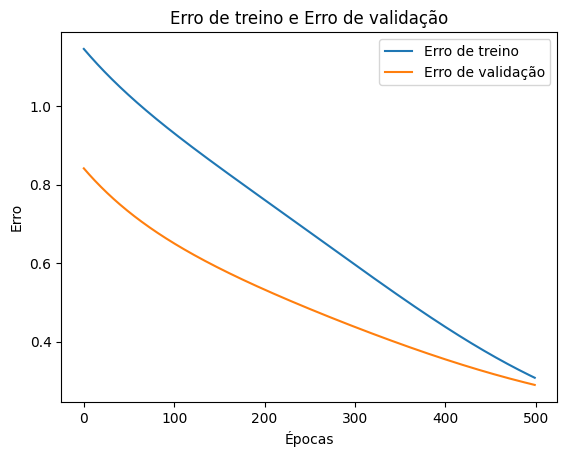

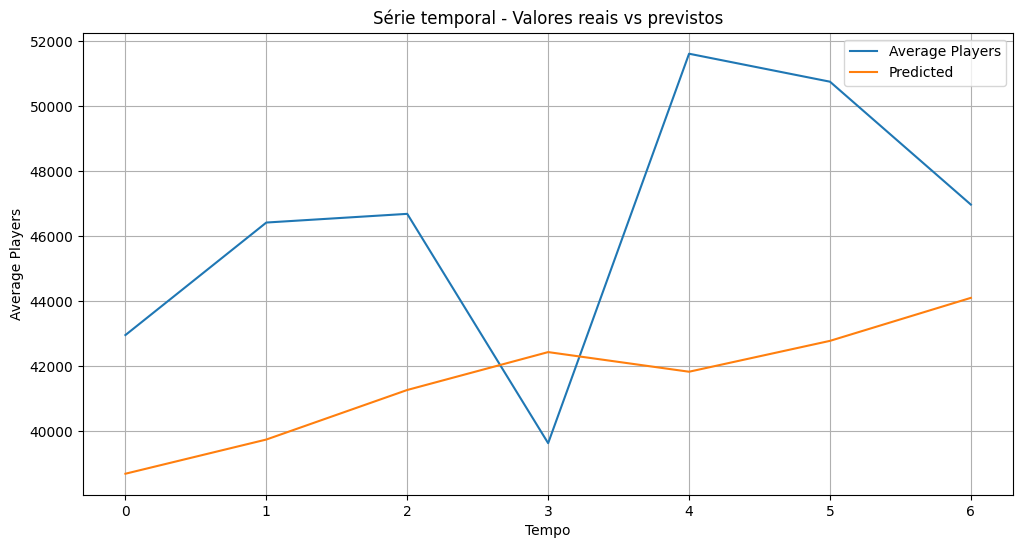

========= Erro de teste =========
6187.33


In [7]:
class LSTM(nn.Module):
    def __init__(self, in_features: int = 3, hidden_size: int = 16, out_features: int = 1):
        """
        Args:
            in_features: Número de features que o dataset possui (recebemos os 3 features)
            out_features: Previsão do modelo (prevemos apenas a quantidade média de jogadores)
        """
        super(LSTM, self).__init__() # instancia o nn.Module
        self.lstm = nn.LSTM(in_features, hidden_size=hidden_size, batch_first=True)
        # Camada de mapeamento
        self.l1 = nn.Linear(hidden_size, out_features)

    def forward(self, input):
        """
        Args:
            input: (batch_size, seq_len, in_features)
        """
        out, (a, c) = self.lstm(input)
        a_last = a[-1]
        
        out = self.l1(a_last)

        return out

EPOCHS = 500
BATCH_SIZE = 32
HIDDEN_SIZE = 16
ETA = 0.001
PATH = "db/Warframe_Player_Data_Features.csv"

# --- 1. Preparação dos dataloaders ---
train_dl, val_dl, test_dl, mean, std = prepareData(PATH)

# --- 2. Instanciação do modelo, da função de erro e do algoritmo de cálculo de gradiente ---
model = LSTM(hidden_size=HIDDEN_SIZE).to(DEVICE)
loss_func = nn.MSELoss()
optimizer = torch.optim.SGD(
   model.parameters(),
   lr = ETA 
)

# --- 3. Etapa de treinamento e validação ---
# Armazenamos os erros seguindo o padrão {época: erro obtido}
train_loss = {}
val_loss = {}
for i in range(EPOCHS):
    loss = trainEpoch(model, train_dl, optimizer, loss_func)
    train_loss[i] = loss

    loss = evaluateEpoch(model, val_dl, loss_func)
    val_loss[i] = loss

plotLosses(train_loss, val_loss, "Erro de treino", "Erro de validação", "Gráfico_de_erros_M3.png")
true_values, predicted_values = generateSeries(model, test_dl, mean, std)
plotSeries(true_values, predicted_values, "Average Players", "Predicted", "Grafico_serie_temporal3.png")
accuracy = testModel(model, test_dl, mean, std)
print("========= Erro de teste =========")
print(f"{accuracy:.2f}")

# Modelo 4 - 32 neurônios na célula LSTM
---

## Resultados obtidos

Curiosamente, este modelo obteve uma precisão menor que o anterior. Pode indicar que estamos chegando a um modelo desnecessariamente complexo para o problema.

Portanto, vamos mudar o foco da quantidade de neurônios na célula LSTM para a taxa de aprendizado.

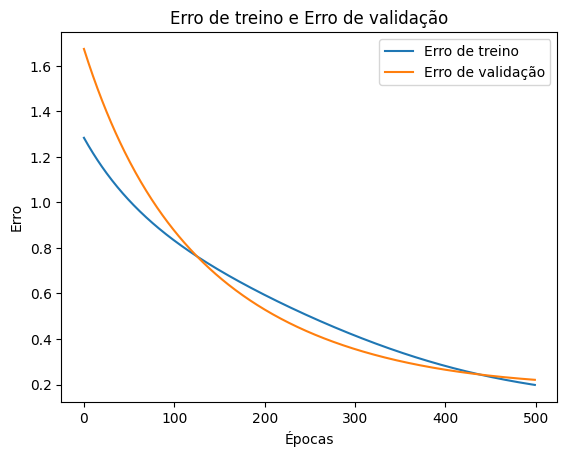

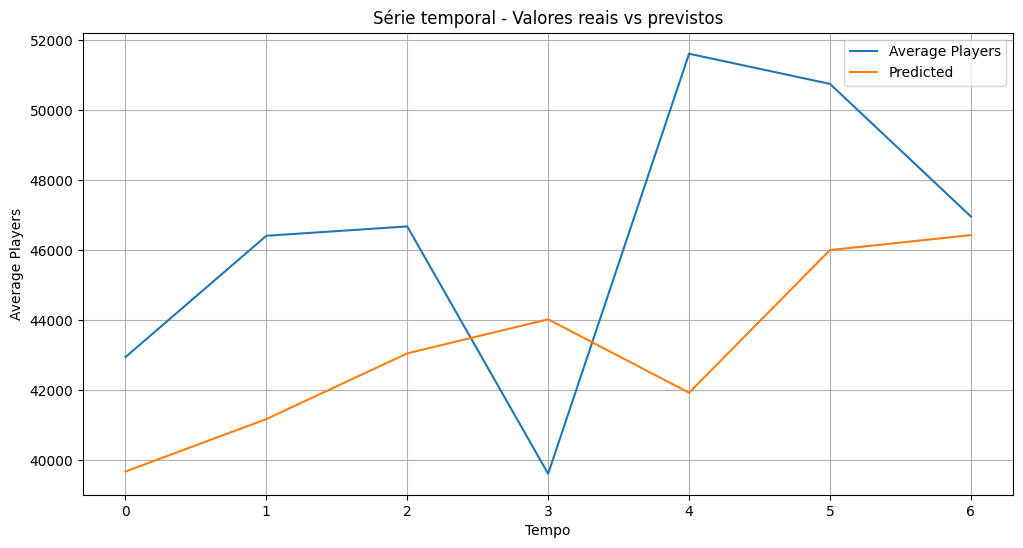

========= Erro de teste =========
5170.83


In [8]:
class LSTM(nn.Module):
    def __init__(self, in_features: int = 3, hidden_size: int = 32, out_features: int = 1):
        """
        Args:
            in_features: Número de features que o dataset possui (recebemos os 3 features)
            out_features: Previsão do modelo (prevemos apenas a quantidade média de jogadores)
        """
        super(LSTM, self).__init__() # instancia o nn.Module
        self.lstm = nn.LSTM(in_features, hidden_size=hidden_size, batch_first=True)
        # Camada de mapeamento
        self.l1 = nn.Linear(hidden_size, out_features)

    def forward(self, input):
        """
        Args:
            input: (batch_size, seq_len, in_features)
        """
        out, (a, c) = self.lstm(input)
        a_last = a[-1]
        
        out = self.l1(a_last)

        return out

EPOCHS = 500
BATCH_SIZE = 32
HIDDEN_SIZE = 32
ETA = 0.001
PATH = "db/Warframe_Player_Data_Features.csv"

# --- 1. Preparação dos dataloaders ---
train_dl, val_dl, test_dl, mean, std = prepareData(PATH)

# --- 2. Instanciação do modelo, da função de erro e do algoritmo de cálculo de gradiente ---
model = LSTM(hidden_size=HIDDEN_SIZE).to(DEVICE)
loss_func = nn.MSELoss()
optimizer = torch.optim.SGD(
   model.parameters(),
   lr = ETA 
)

# --- 3. Etapa de treinamento e validação ---
# Armazenamos os erros seguindo o padrão {época: erro obtido}
train_loss = {}
val_loss = {}
for i in range(EPOCHS):
    loss = trainEpoch(model, train_dl, optimizer, loss_func)
    train_loss[i] = loss

    loss = evaluateEpoch(model, val_dl, loss_func)
    val_loss[i] = loss

plotLosses(train_loss, val_loss, "Erro de treino", "Erro de validação", "Gráfico_de_erros_M4.png")
true_values, predicted_values = generateSeries(model, test_dl, mean, std)
plotSeries(true_values, predicted_values, "Average Players", "Predicted", "Grafico_serie_temporal4.png")
accuracy = testModel(model, test_dl, mean, std)
print("========= Erro de teste =========")
print(f"{accuracy:.2f}")

# Modelo 5 - 16 neurônios na célula LSTM
---

## Resultados obtidos

Ao reduzir a quantidade de neurônios e aumentar a taxa de aprendizado, verificamos uma proximidade maior dos valores reais. Além disso, verificamos que o modelo acompanhou a distribuição com certa semelhança em grande parte das execuções.

Pelo erro de teste, podemos afirmar que este modelo atingiu a melhor precisão comparado aos 4 anteriores.

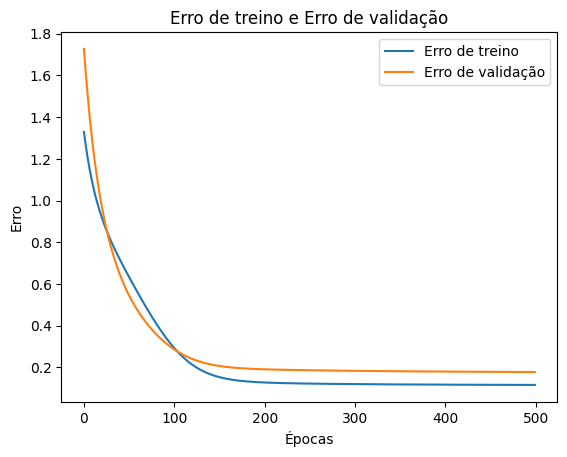

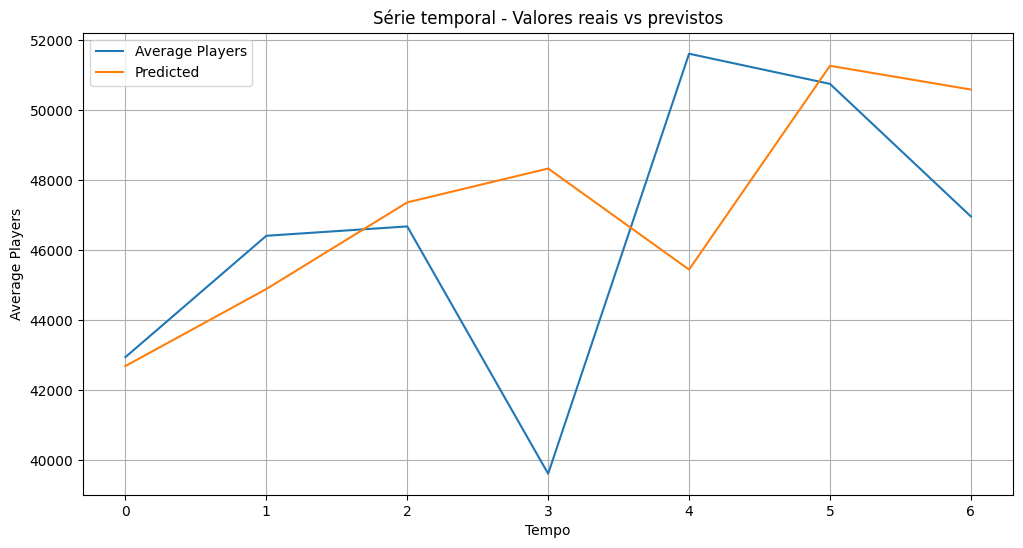

========= Erro de teste =========
4312.20


In [9]:
class LSTM(nn.Module):
    def __init__(self, in_features: int = 3, hidden_size: int = 16, out_features: int = 1):
        """
        Args:
            in_features: Número de features que o dataset possui (recebemos os 3 features)
            out_features: Previsão do modelo (prevemos apenas a quantidade média de jogadores)
        """
        super(LSTM, self).__init__() # instancia o nn.Module
        self.lstm = nn.LSTM(in_features, hidden_size=hidden_size, batch_first=True)
        # Camada de mapeamento
        self.l1 = nn.Linear(hidden_size, out_features)

    def forward(self, input):
        """
        Args:
            input: (batch_size, seq_len, in_features)
        """
        out, (a, c) = self.lstm(input)
        a_last = a[-1]
        
        out = self.l1(a_last)

        return out

EPOCHS = 500
BATCH_SIZE = 32
HIDDEN_SIZE = 16
ETA = 0.005
PATH = "db/Warframe_Player_Data_Features.csv"

# --- 1. Preparação dos dataloaders ---
train_dl, val_dl, test_dl, mean, std = prepareData(PATH)

# --- 2. Instanciação do modelo, da função de erro e do algoritmo de cálculo de gradiente ---
model = LSTM(hidden_size=HIDDEN_SIZE).to(DEVICE)
loss_func = nn.MSELoss()
optimizer = torch.optim.SGD(
   model.parameters(),
   lr = ETA 
)

# --- 3. Etapa de treinamento e validação ---
# Armazenamos os erros seguindo o padrão {época: erro obtido}
train_loss = {}
val_loss = {}
for i in range(EPOCHS):
    loss = trainEpoch(model, train_dl, optimizer, loss_func)
    train_loss[i] = loss

    loss = evaluateEpoch(model, val_dl, loss_func)
    val_loss[i] = loss

plotLosses(train_loss, val_loss, "Erro de treino", "Erro de validação", "Gráfico_de_erros_M5.png")
true_values, predicted_values = generateSeries(model, test_dl, mean, std)
plotSeries(true_values, predicted_values, "Average Players", "Predicted", "Grafico_serie_temporal5.png")
accuracy = testModel(model, test_dl, mean, std)
print("========= Erro de teste =========")
print(f"{accuracy:.2f}")

# Discussão final
---

Com o melhor modelo, atingimos um erro de aproximadamente 4000 jogadores. Possivelmente, um dos fatores limitantes para o modelo foi a baixa quantidade de dados: pouco mais de 100 exemplos.

Ainda assim o modelo atingiu uma precisão satisfatória, com distância máxima de por volta de 10% dos valores reais. Com certeza valores melhores podem ser atingidos com um ajuste mais fino dos hiperparâmetros do LSTM, ou considerando redes recorrentes profundas. Contudo, dada a simplicidade do modelo, temos uma solução eficiente para o problema.